---
date: "2026-06-19"
date-modified: last-modified
format:
  html:
    toc: true
---


# Geometric and Negative Binomial Distributions

Both the Geometric and Negative Binomial distributions describe the "waiting time" in a sequence of independent [Bernoulli trials](bernoulli-and-binomial-distributions.ipynb#the-bernoulli-trial-story) (where each trial results in either a Success or a Failure). 

While the standard Binomial distribution counts the *number of successes* in a *fixed number of trials*, these distributions flip the concept: they count the *number of failures* before achieving a *fixed number of successes*.

---

## The Geometric Distribution

**The Intuition (The Story):**
Imagine you are repeatedly flipping a biased coin that lands Heads (Success) with probability $p$. You keep flipping until you see your very first Head, and then you stop immediately. The Geometric distribution measures **how many Tails (Failures) you flipped before that first Head.**

*(Note on Convention: In advanced probability, the Geometric distribution specifically counts the number of failures $k$. Another variation, sometimes called the "First Success" distribution, counts the total number of trials $k+1$. We will use the failure-counting convention here).*

**The Probability Mass Function (PMF):**
Let $X \sim \text{Geom}(p)$ be the number of failures before the first success. 
For $X$ to equal exactly $k$, you must observe exactly $k$ failures in a row, followed immediately by exactly 1 success. Because the trials are independent, we multiply their probabilities:

$$P(X = k) = (1-p)^k p \quad \text{for } k = 0, 1, 2, \dots$$

---

## The Negative Binomial Distribution

**The Intuition (The Story):**
The Negative Binomial distribution is the direct generalization of the Geometric distribution. Instead of stopping after the *first* success, you wait until you have accumulated exactly $r$ successes. 

If $X \sim \text{NBin}(r, p)$, then $X$ measures the **total number of failures that occur before the $r$-th success.**

Because waiting for $r$ successes is the exact same as waiting for 1 success, restarting, waiting for another 1 success, and repeating this $r$ times, a Negative Binomial random variable is simply the sum of $r$ independent Geometric random variables.

**The Probability Mass Function (PMF):**
Suppose you want to find the probability of exactly $n$ failures before the $r$-th success ($X = n$). 
* In total, you will perform exactly $n + r$ trials. 
* By definition, the very last trial **must** be your $r$-th success (otherwise, you would have stopped earlier!).
* This leaves $n + r - 1$ previous trials. Within those earlier trials, there must be exactly $r - 1$ successes and $n$ failures.
* The number of ways to arrange those $r-1$ successes among the $n+r-1$ slots is given by "n choose k": $\binom{n+r-1}{r-1}$.
* Every specific valid sequence has $r$ successes and $n$ failures, giving a probability of $p^r (1-p)^n$.

Multiplying the number of combinations by the probability of each combination gives the PMF:

$$P(X = n) = \binom{n+r-1}{r-1} p^r (1-p)^n \quad \text{for } n = 0, 1, 2, \dots$$

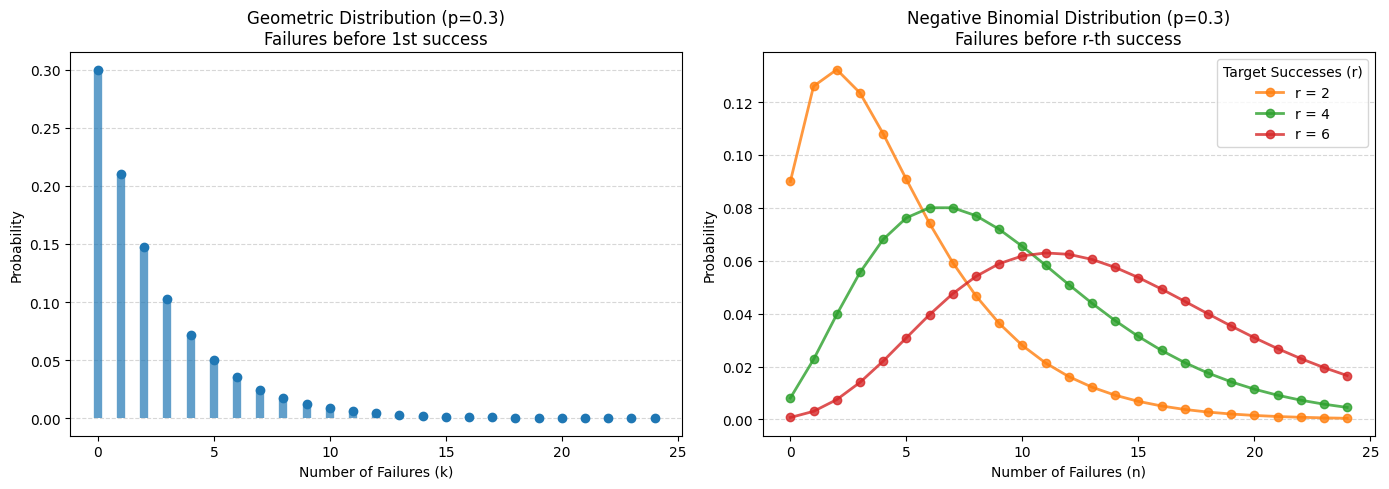

In [1]:
#| label: fig-waiting-time-distributions
#| fig-cap: "Comparing the Geometric and Negative Binomial distributions. Notice how the Geometric distribution always peaks at 0, while waiting for multiple successes (Negative Binomial) shifts the peak outward."

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom, nbinom

plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Common success probability
p = 0.3
x_vals = np.arange(0, 25)

# --- Plot 1: Geometric Distribution ---
# Note: scipy.stats.geom counts total trials (k+1). 
# We evaluate it at x_vals + 1 to align with our failure-counting convention (k).
geom_pmf = geom.pmf(x_vals + 1, p)
axes[0].vlines(x_vals, 0, geom_pmf, colors='#1f77b4', lw=6, alpha=0.7)
axes[0].plot(x_vals, geom_pmf, 'o', color='#1f77b4')
axes[0].set_title(f"Geometric Distribution (p={p})\nFailures before 1st success")
axes[0].set_xlabel("Number of Failures (k)")
axes[0].set_ylabel("Probability")
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Negative Binomial Distribution ---
# We will plot for r = 2, r = 4, and r = 6
colors = ['#ff7f0e', '#2ca02c', '#d62728']
r_values = [2, 4, 6]

for i, r in enumerate(r_values):
    nbin_pmf = nbinom.pmf(x_vals, r, p)
    axes[1].plot(x_vals, nbin_pmf, '-o', color=colors[i], label=f'r = {r}', alpha=0.8, lw=2)

axes[1].set_title(f"Negative Binomial Distribution (p={p})\nFailures before r-th success")
axes[1].set_xlabel("Number of Failures (n)")
axes[1].set_ylabel("Probability")
axes[1].legend(title="Target Successes (r)")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()